# Week 2 — Deep Exploratory Analysis & Feature Engineering
**Dataset:** Steel Industry Energy Consumption Dataset (UCI)

This notebook covers Part 1 of the Week 2 internship task: loading the data,
engineering new time-based and ratio features, detecting outliers, and
visualizing the key relationships and patterns that drive energy usage.

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## 2. Load the Dataset and Re-examine Its Structure

In [2]:
df = pd.read_csv('data/Steel_industry_data.csv')
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())
df.head()


Shape: (35040, 11)

Column dtypes:
date                                        str
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                                  str
Day_of_week                                 str
Load_Type                                   str
dtype: object

Missing values per column:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week      

In [3]:
print(df.describe())


          Usage_kWh  ...           NSM
count  35040.000000  ...  35040.000000
mean      27.386892  ...  42750.000000
std       33.444380  ...  24940.534317
min        0.000000  ...      0.000000
25%        3.200000  ...  21375.000000
50%        4.570000  ...  42750.000000
75%       51.237500  ...  64125.000000
max      157.180000  ...  85500.000000

[8 rows x 7 columns]


## 3. Convert Date Column and Extract Time Features

The raw `date` column mixes two textual formats in the source spreadsheet
(`YYYY-MM-DD HH:MM:SS` and `DD/MM/YYYY HH:MM`), so both formats are parsed
and combined to avoid losing any rows.

In [4]:
parsed_iso = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
parsed_slash = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M', errors='coerce')
df['date'] = parsed_iso.combine_first(parsed_slash)
assert df['date'].isna().sum() == 0, "Some dates failed to parse"

df['Hour'] = df['date'].dt.hour
df['DayOfWeek_Num'] = df['date'].dt.dayofweek        # 0 = Monday
df['Month'] = df['date'].dt.month
df['Is_Weekend'] = df['DayOfWeek_Num'].isin([5, 6]).astype(int)

print("Date range:", df['date'].min(), "to", df['date'].max())
print(df[['date', 'Hour', 'DayOfWeek_Num', 'Month', 'Is_Weekend']].head())


Date range: 2018-01-01 00:00:00 to 2018-12-31 23:45:00
                 date  Hour  DayOfWeek_Num  Month  Is_Weekend
0 2018-01-01 00:15:00     0              0      1           0
1 2018-01-01 00:30:00     0              0      1           0
2 2018-01-01 00:45:00     0              0      1           0
3 2018-01-01 01:00:00     1              0      1           0
4 2018-01-01 01:15:00     1              0      1           0


## 4. Feature Engineering: Power_Factor_Ratio

`Power_Factor_Ratio = Leading_Current_Power_Factor / Lagging_Current_Power_Factor`

In [5]:
df['Power_Factor_Ratio'] = df['Leading_Current_Power_Factor'] / df['Lagging_Current_Power_Factor']
df['Power_Factor_Ratio'] = df['Power_Factor_Ratio'].replace([np.inf, -np.inf], np.nan)
print(df['Power_Factor_Ratio'].describe())
print("\nRows with NaN ratio (from zero lagging PF):", df['Power_Factor_Ratio'].isna().sum())


count    35039.000000
mean         1.173234
std          0.587466
min          0.125000
25%          1.001809
50%          1.136105
75%          1.579280
max          2.707093
Name: Power_Factor_Ratio, dtype: float64

Rows with NaN ratio (from zero lagging PF): 1


## 5. Feature Engineering: High_Load Binary Flag

Rows where `Usage_kWh` is above the 75th percentile are flagged as `High_Load = 1`.

In [6]:
p75 = df['Usage_kWh'].quantile(0.75)
df['High_Load'] = (df['Usage_kWh'] > p75).astype(int)
print(f"75th percentile of Usage_kWh: {p75:.3f}")
print(df['High_Load'].value_counts())


75th percentile of Usage_kWh: 51.237
High_Load
0    26280
1     8760
Name: count, dtype: int64


## 6. Outlier Detection (IQR Method) + Boxplot

Q1=3.200, Q3=51.237, IQR=48.037
Lower bound=-68.856, Upper bound=123.294
Number of outliers in Usage_kWh: 328 (0.94% of data)


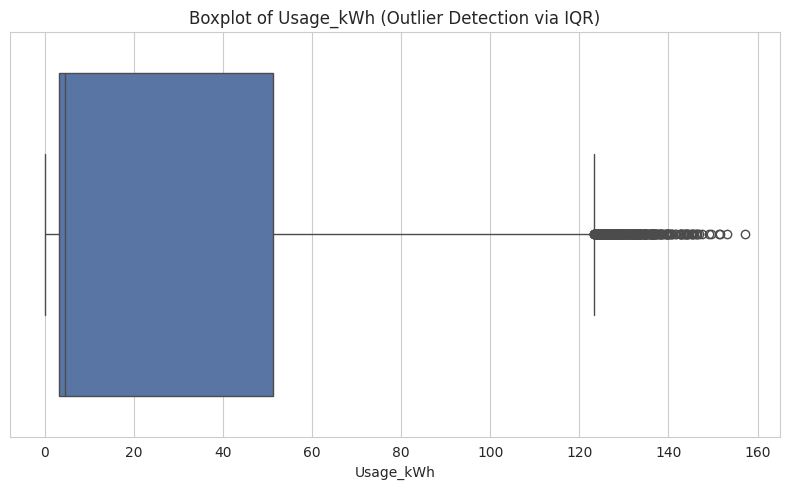

In [7]:
Q1 = df['Usage_kWh'].quantile(0.25)
Q3 = df['Usage_kWh'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Usage_kWh'] < lower_bound) | (df['Usage_kWh'] > upper_bound)]

print(f"Q1={Q1:.3f}, Q3={Q3:.3f}, IQR={IQR:.3f}")
print(f"Lower bound={lower_bound:.3f}, Upper bound={upper_bound:.3f}")
print(f"Number of outliers in Usage_kWh: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of data)")

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Usage_kWh'], color='#4C72B0')
plt.title('Boxplot of Usage_kWh (Outlier Detection via IQR)')
plt.xlabel('Usage_kWh')
plt.tight_layout()
plt.show()


## 7. Correlation Heatmap

Top 3 features most correlated with Usage_kWh:
CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
High_Load                               0.86784
Name: Usage_kWh, dtype: float64


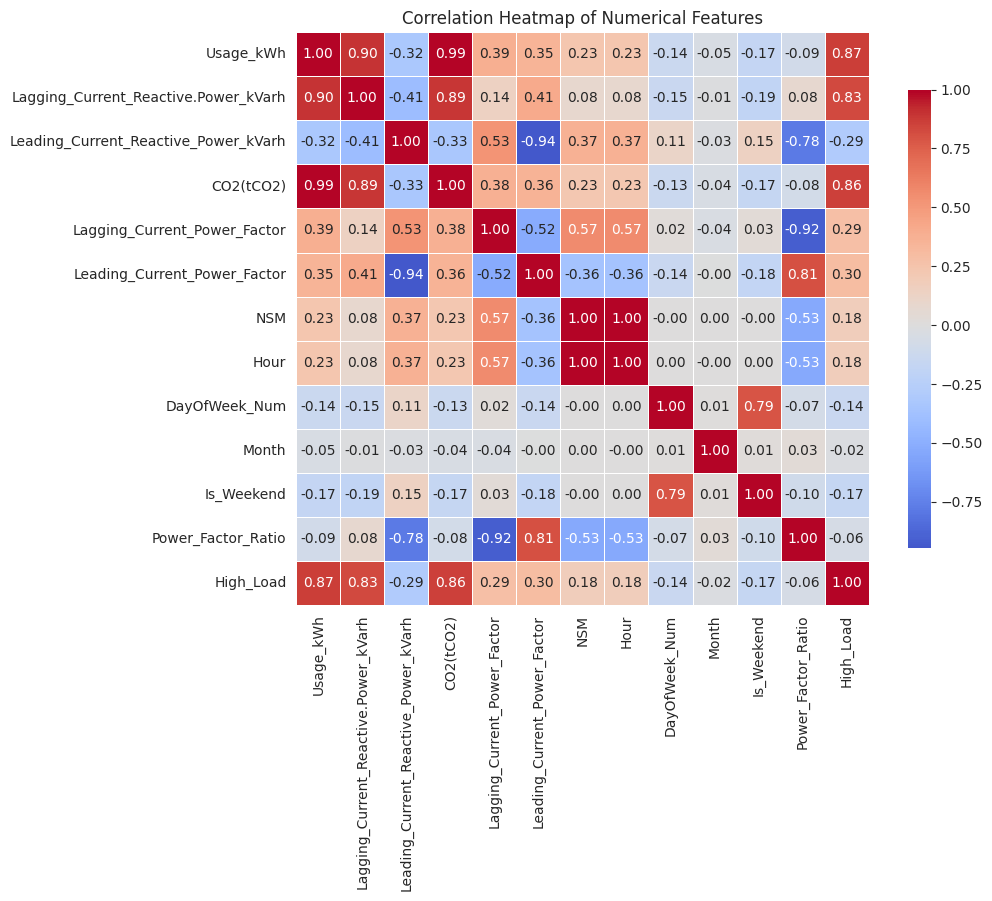

In [8]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

usage_corr = corr['Usage_kWh'].drop('Usage_kWh').sort_values(key=abs, ascending=False)
print("Top 3 features most correlated with Usage_kWh:")
print(usage_corr.head(3))


**Top 3 correlated features:** `CO2(tCO2)` (~0.99), `Lagging_Current_Reactive.Power_kVarh`
(~0.90), and `High_Load` (~0.87, expected since it is derived directly from `Usage_kWh`).
CO2 emissions track energy usage almost 1:1, which makes physical sense — more
electricity drawn means more CO2 generated at the plant.

## 8. Average Energy Consumption by Load Type

Load_Type
Light_Load       8.626207
Medium_Load     38.445394
Maximum_Load    59.265314
Name: Usage_kWh, dtype: float64


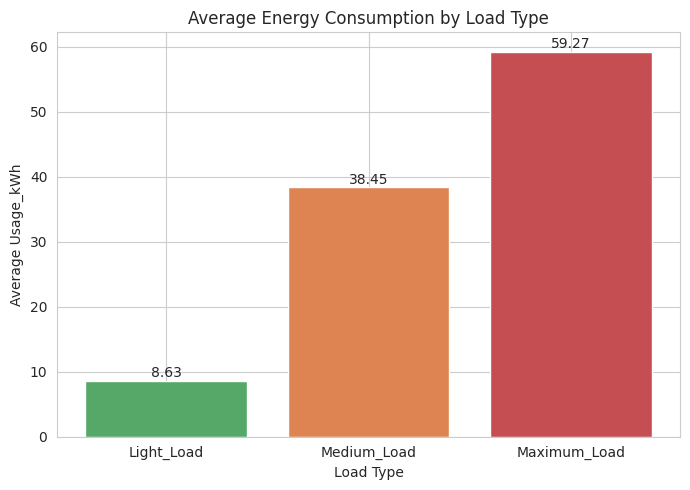

In [9]:
load_avg = df.groupby('Load_Type')['Usage_kWh'].mean().reindex(
    ['Light_Load', 'Medium_Load', 'Maximum_Load'])
print(load_avg)

plt.figure(figsize=(7, 5))
bars = plt.bar(load_avg.index, load_avg.values, color=['#55A868', '#DD8452', '#C44E52'])
plt.title('Average Energy Consumption by Load Type')
plt.xlabel('Load Type')
plt.ylabel('Average Usage_kWh')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.2f}', ha='center')
plt.tight_layout()
plt.show()


## 9. Average Energy Usage by Hour of Day

Hour
0      7.870075
1      6.072479
2      4.428390
3      4.358041
4      4.309438
5      4.245548
6      4.223705
7      4.502075
8     37.704795
9     58.551733
10    55.874733
11    57.097459
12    18.461000
13    39.019500
14    56.155260
15    55.637541
16    55.799582
17    43.833096
18    33.020932
19    38.208514
20    37.477226
21    13.777363
22     8.658918
23     7.998014
Name: Usage_kWh, dtype: float64


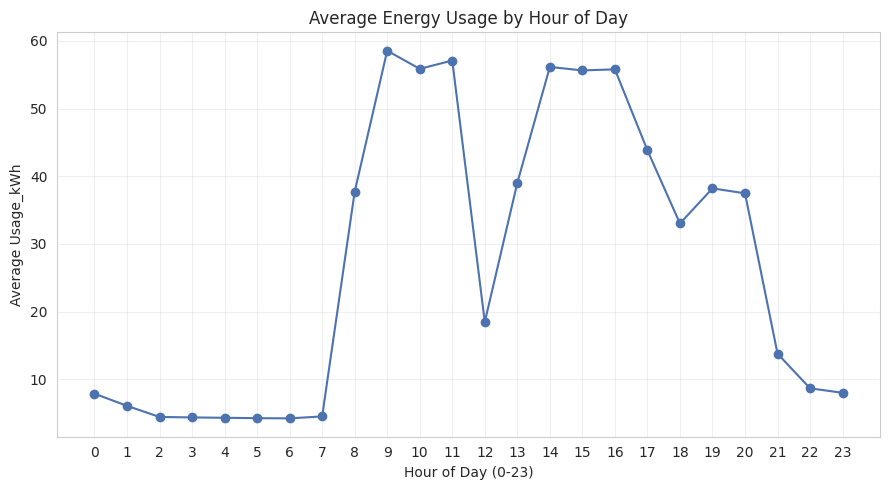

In [10]:
hourly_avg = df.groupby('Hour')['Usage_kWh'].mean()
print(hourly_avg)

plt.figure(figsize=(9, 5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o', color='#4C72B0')
plt.title('Average Energy Usage by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Usage_kWh')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Save Engineered Dataset for Part 2

In [11]:
df.to_csv('data/Steel_industry_data_engineered.csv', index=False)
print("Engineered dataset saved to data/Steel_industry_data_engineered.csv")
print("Final columns:", df.columns.tolist())
print("Final shape:", df.shape)


Engineered dataset saved to data/Steel_industry_data_engineered.csv
Final columns: ['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeek_Num', 'Month', 'Is_Weekend', 'Power_Factor_Ratio', 'High_Load']
Final shape: (35040, 17)


## EDA Summary 

**Data quality issues found.** The dataset itself has no missing values, but
the raw `date` column silently mixed two different text formats
(`YYYY-MM-DD HH:MM:SS` and `DD/MM/YYYY HH:MM`), which would silently produce
mass `NaT` values if parsed with a single fixed format — a subtle trap for
anyone loading this data naively. `Power_Factor_Ratio` also produced one
`NaN` from a zero `Lagging_Current_Power_Factor` reading, which needs
explicit handling before modeling. The IQR method flagged 328 rows
(0.94%) as outliers in `Usage_kWh`, concentrated at the high end — these
correspond to genuine maximum-load operating periods rather than data errors.

**Top correlated features.** `CO2(tCO2)` correlates almost perfectly with
`Usage_kWh` (~0.99), since emissions are a near-direct function of power
drawn. `Lagging_Current_Reactive.Power_kVarh` is the next strongest
(~0.90), reflecting how reactive power scales with real load on
inductive industrial equipment.

**Most interesting pattern.** Energy usage follows a strong, repeatable
daily rhythm: consumption is low and flat overnight (roughly 4–8 kWh from
midnight to 7 AM), then jumps sharply at 8 AM to 35–58 kWh during working
hours, with a distinct midday dip around 12 PM (likely a shift-change or
lunch break) before dropping off again after 9 PM.

**Hypothesis on energy spikes.** Spikes align tightly with the start of
production shifts and `Load_Type == Maximum_Load` periods. This suggests
spikes are driven by scheduled batch operations (e.g., furnace startups or
heavy machinery cycles) rather than random fluctuation, meaning usage is
largely predictable from time-of-day and shift/load-type features alone.